<a href="https://colab.research.google.com/github/BRAGADHEES/IT-support-Task-Assignment-Project/blob/main/Ecommerce_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('/content/sample_data/ecommerce_sales_data.csv')

# Show the first few rows to confirm it loaded correctly
df.head()


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('/content/sample_data/ecommerce_sales_data.csv')

# Show the first few rows to confirm it loaded correctly
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


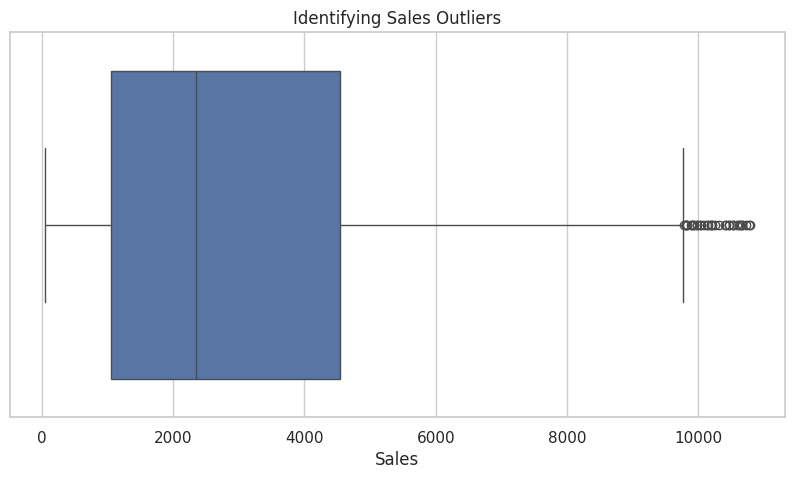

Total outliers found: 35


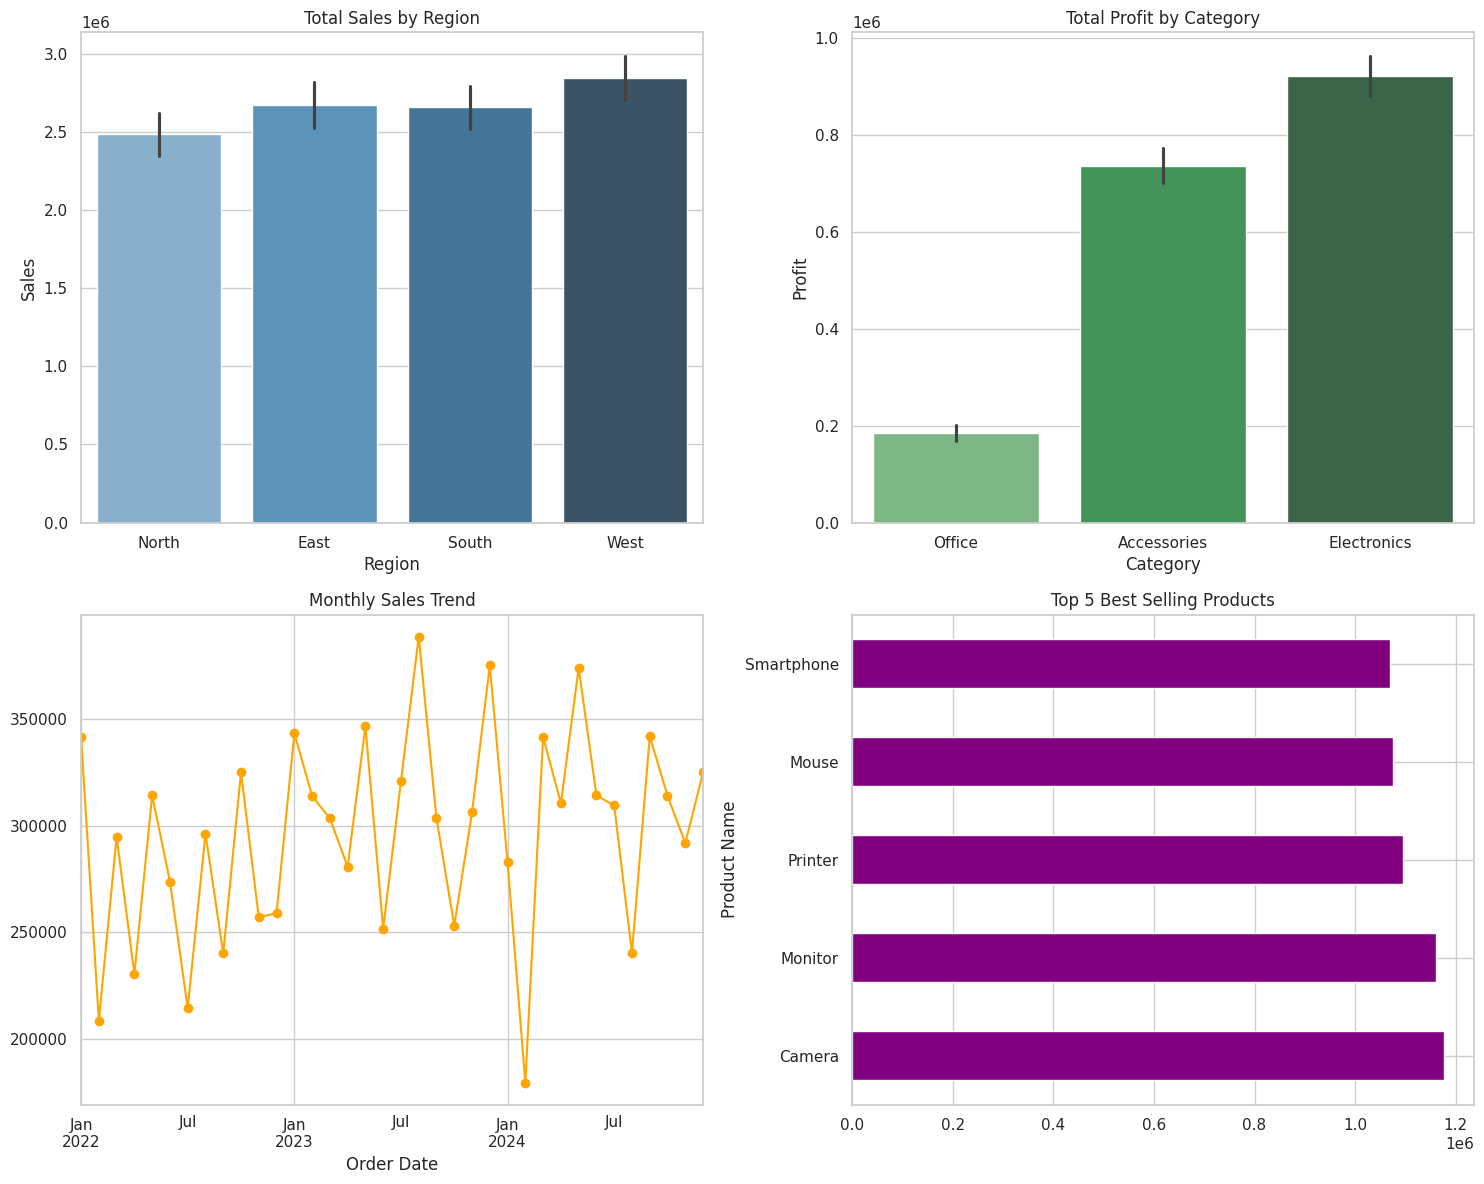

In [11]:


# Visualize outliers with a Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Sales'])
plt.title('Identifying Sales Outliers')
plt.show()

# Calculate IQR for Sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data to see outliers
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"Total outliers found: {len(outliers)}")

# Convert 'Order Date' to datetime type
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Set the visual style
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sales by Region
sns.barplot(data=df, x='Region', y='Sales', estimator=sum, ax=axes[0,0], hue='Region', palette='Blues_d', legend=False)
axes[0,0].set_title('Total Sales by Region')

# 2. Profit by Category
sns.barplot(data=df, x='Category', y='Profit', estimator=sum, ax=axes[0,1], hue='Category', palette='Greens_d', legend=False)
axes[0,1].set_title('Total Profit by Category')

# 3. Monthly Sales Trend
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', ax=axes[1,0], color='orange')
axes[1,0].set_title('Monthly Sales Trend')

# 4. Top 5 Products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(5)
top_products.plot(kind='barh', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top 5 Best Selling Products')

plt.tight_layout()
plt.show()

# Save to a new CSV
df.to_csv('cleaned_ecommerce_data.csv', index=False)